# Bildkompression mit Singulärwertzerlegung

In [3]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt



##Bild-Upload

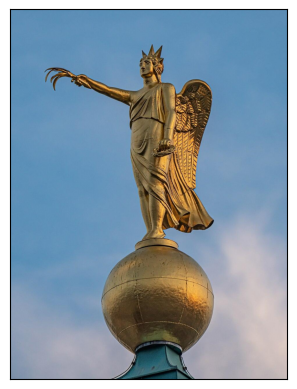

In [4]:

img = Image.open('./Friedensengel_100kB.jpg')

#Bildanzeige mit matplotlib
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(img)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)

## Umwandlung in Schwarzweiß-Bild

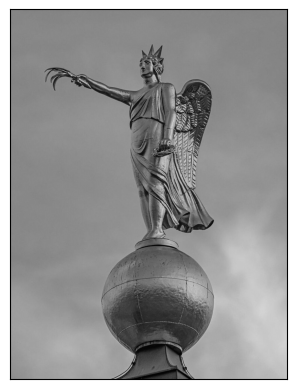

In [5]:
#Umwandlung in Grauwerte
img = img.convert('L')

#Bildanzeige mit matplotlib
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(img,cmap='gray')
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)

In [27]:
A= np.array(img)


## Dimension des Bildes

In [28]:
[m,n]=A.shape
[m,n]

[1280, 960]

## Anzeige der links oberen 10x10 Werte der Bildmatrix

In [29]:
A[0:10,0:10]

array([[133, 133, 133, 133, 133, 133, 133, 133, 133, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 133, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 132, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 132, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 131, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 132, 132, 131, 131, 130, 130, 128, 129],
       [133, 132, 132, 132, 131, 131, 130, 130, 133, 132]], dtype=uint8)

##Singulärwertzerlegung

In [30]:
# Vh ist die Transponierte von V
U,S,Vh=np.linalg.svd(A, full_matrices=True)


In [31]:
U.shape

(1280, 1280)

In [32]:
S.shape

(960,)

In [33]:
Vh.shape

(960, 960)

##Anzahl genutzter Singulärwerte

In [34]:
# Anzahl verwendeter Singulärwerte
k=50

## Kompression von U und V auf k Spalten und S auf k Werte

In [35]:
# Kompression auf k Spalten von U und k Zeilen von Vh
U_komp = U[:,0:k]
S_komp = S[0:k]
Vh_komp = Vh[0:k,:]


## Berechnung der komprimierten Bildmatrix

In [36]:


A_komp = np.matmul(U_komp*S_komp,Vh_komp)


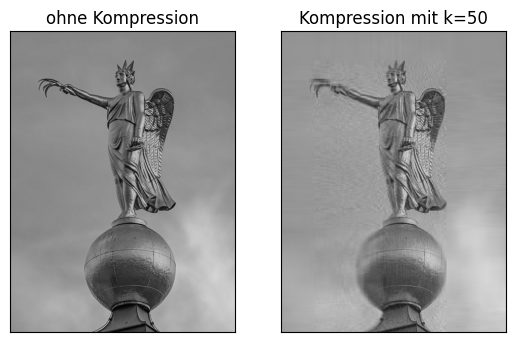

In [37]:

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(A,cmap='gray')
ax1.set_title('ohne Kompression')
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(A_komp,cmap='gray')
ax2.set_title("Kompression mit k="+str(k))
ax2.axes.get_xaxis().set_visible(False)
ax2.axes.get_yaxis().set_visible(False)

plt.show()

In [38]:
img_komp = Image.fromarray(A_komp)
img_komp.show()
img.show()